# Week 3 — The Likelihood Surface and MLE on NHANES

*INFO 521 worked notebook (Module 3). Companion to lectures m3a/m3b. Needs the course
environment (`info521` package).*

Module 1 *chose* squared error. This notebook re-derives the same fit from a **model**:
Gaussian noise around the line. Maximizing the log-likelihood $\ell(\mathbf{w})$ *is*
minimizing $\mathcal{L}$ — and the likelihood pays two dividends the loss never did:
an estimate of the noise, and (lecture m3b) uncertainty in $\hat{\mathbf{w}}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from info521.data import load_clinical, primary_predictor

BLUE, VERMILLION, GREEN, ORANGE = "#0072B2", "#D55E00", "#009E73", "#E69F00"
rng = np.random.default_rng(521)

ds  = load_clinical()
age = primary_predictor(ds); sbp = ds["y"]
z   = (age - age.mean()) / age.std()
X   = np.column_stack([np.ones_like(z), z])
N   = len(sbp)

w_hat = np.linalg.solve(X.T @ X, X.T @ sbp)     # the Module-1 fit
resid = sbp - X @ w_hat
s2    = float((resid**2).mean())                # σ̂² = (1/N)Σr²
print(f"ŵ = {w_hat.round(2)},  σ̂ = {np.sqrt(s2):.2f} mmHg")

ŵ = [121.49   6.48],  σ̂ = 15.93 mmHg


## The log-likelihood profile

Fix $w_0$ at $\hat{w}_0$ and sweep the slope: the log-likelihood
$\ell(w_1) = -\frac{N}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_n r_n^2$
is a smooth concave arch — and its peak lands exactly on the least-squares slope.

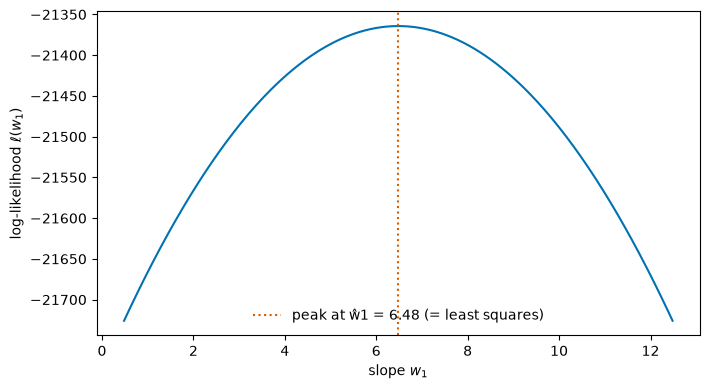

In [2]:
w1g = np.linspace(w_hat[1] - 6, w_hat[1] + 6, 300)
sse = np.array([((sbp - (w_hat[0] + w1*z))**2).sum() for w1 in w1g])
ll  = -N/2*np.log(2*np.pi*s2) - sse/(2*s2)

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(w1g, ll, color=BLUE)
ax.axvline(w_hat[1], color=VERMILLION, linestyle=":",
           label=f"peak at ŵ1 = {w_hat[1]:.2f} (= least squares)")
ax.set_xlabel("slope $w_1$"); ax.set_ylabel("log-likelihood $\\ell(w_1)$")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## Model check: are residuals Gaussian-ish?

A likelihood is an *assumption*. Check it: overlay the fitted
$\mathcal{N}(0, \hat{\sigma}^2)$ on the residual histogram.

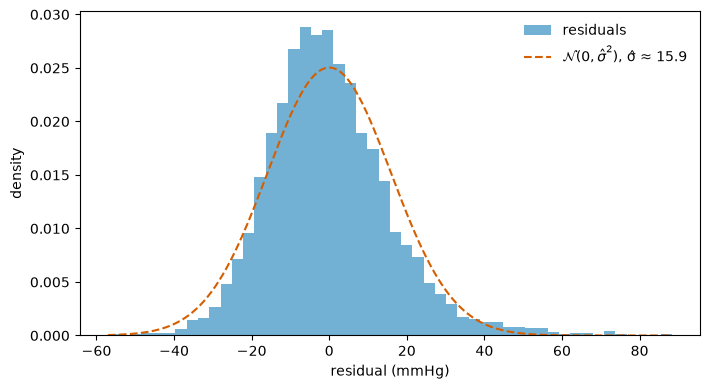

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4))
ax.hist(resid, bins=50, density=True, color=BLUE, alpha=0.55, label="residuals")
t = np.linspace(resid.min(), resid.max(), 300)
ax.plot(t, np.exp(-t**2/(2*s2))/np.sqrt(2*np.pi*s2), "--", color=VERMILLION,
        label=f"$\\mathcal{{N}}(0, \\hat{{\\sigma}}^2)$, σ̂ ≈ {np.sqrt(s2):.1f}")
ax.set_xlabel("residual (mmHg)"); ax.set_ylabel("density")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Bell-shaped in the bulk, but **right-skewed** — hypertensive spikes give a heavier
positive tail than the Gaussian predicts. Useful, not true. (Binarizing that tail is
exactly what Module 5 / Project 2 does.)

## The bias of σ̂², watched happening

Theory (lecture m3a): $\mathbb{E}[\hat{\sigma}^2] = \frac{N-D}{N}\sigma^2$ — small samples
*systematically under-estimate* the noise, because the fit chases the sample. Watch it on
real resamples:

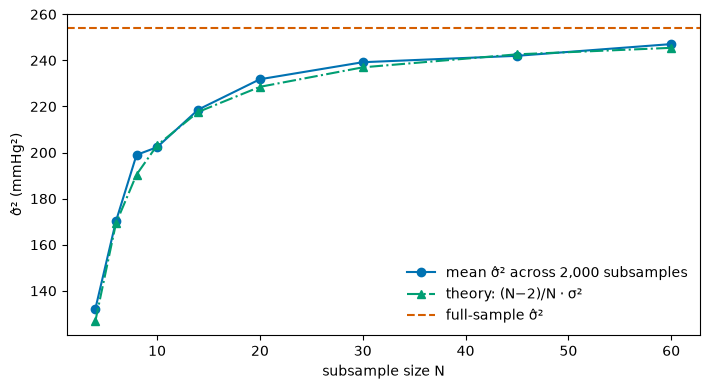

In [4]:
sizes = np.array([4, 6, 8, 10, 14, 20, 30, 45, 60])
mean_s2 = []
for m in sizes:
    vals = []
    for _ in range(2000):
        idx = rng.choice(N, m, replace=False)
        Xi, yi = X[idx], sbp[idx]
        wi = np.linalg.solve(Xi.T @ Xi, Xi.T @ yi)
        vals.append(((yi - Xi @ wi)**2).mean())
    mean_s2.append(np.mean(vals))

fig, ax = plt.subplots(figsize=(7.2, 4))
ax.plot(sizes, mean_s2, "o-", color=BLUE, label="mean σ̂² across 2,000 subsamples")
ax.plot(sizes, (sizes-2)/sizes*s2, "^-.", color=GREEN, label="theory: (N−2)/N · σ²")
ax.axhline(s2, color=VERMILLION, linestyle="--", label="full-sample σ̂²")
ax.set_xlabel("subsample size N"); ax.set_ylabel("σ̂² (mmHg²)")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

The empirical curve rides the $(N-2)/N$ line. Contrast with $\hat{\mathbf{w}}$, which
*is* unbiased (lecture m3b): MLE properties are **checked, not assumed**.

**Try it yourself:** repeat the bias experiment dividing by $N-2$ instead of $N$
inside the loop. Does the bias vanish?